In [14]:
from PyHessian.pyhessian.hessian import hessian
from PyHessian.density_plot import get_esd_plot
from hessian_utils import *
from PyHessian.pyhessian.utils import *
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms
# from keras.datasets import mnist
import matplotlib.pyplot as plt 
import time
import copy
import torch_optimizer as optim

# PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
%matplotlib inline

In [15]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)
cuda = torch.cuda.is_available()
torch.autograd.set_detect_anomaly(True)

cpu


In [16]:
from sklearn.datasets import make_classification

# Generate a random 2-class classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, n_classes=2, random_state=42)

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.int64).to(device)


In [17]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
class _Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 100)
        self.fc2 = nn.Linear(100, 30)
        self.fc3 = nn.Linear(30, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(10, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(16*7*7, 16),
            nn.ReLU(),
            nn.Linear(16, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 16*7*7)
        x = self.linear(x)
        return x

class ConvNet3D(nn.Module):
    def __init__(self):
        super(ConvNet3D, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 20, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 40, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(40*8*8, 30),
            nn.ReLU(),
            nn.Linear(30, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 40*8*8)
        x = self.linear(x)
        return x
    
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(20, 10)
        self.fc2 = nn.Linear(10, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [19]:
# train_X = (train_X / 255.0).to(device)
# test_X = (test_X / 255.0).to(device)
# train_y = torch.tensor(train_y, dtype=torch.int64).to(device)
# test_y = torch.tensor(test_y, dtype=torch.int64).to(device)

# train_X = torch.tensor(train_X).permute(0, 3, 1, 2).float()
# test_X = torch.tensor(test_X).permute(0, 3, 1, 2).float()
# train_X = (train_X / 255.0).to(device)
# test_X = (test_X / 255.0).to(device)
# train_y = torch.tensor(train_y, dtype=torch.int64).to(device)
# test_y = torch.tensor(test_y, dtype=torch.int64).to(device)

In [20]:
dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_X[:1000], train_y[:1000]),
    batch_size=32, shuffle=True)


hessian_loader = (train_X[:50], train_y[:50])

# hessian_loader contains 50 images
# for i in range(50):
#     hessian_loader.append((train_X[i].unsqueeze(0), train_y[i].unsqueeze(0)))

In [21]:
model_base = Net().to(device)
model_SGD = copy.deepcopy(model_base)
model_Adam = copy.deepcopy(model_base)
model_curvy = copy.deepcopy(model_base)

criterion = nn.CrossEntropyLoss()

In [22]:
train_losses_SGD = []
train_losses_Adam = []
train_losses_curvy = []
traces_SGD = []
traces_Adam = []
traces_curvy = []
epochs = 30
n_iter = 100

In [23]:
# curvature_SGD = []
# curvature_Adam = []

hessian_SGD = hessian(model_SGD, criterion, data = hessian_loader, cuda=cuda)
hessian_Adam = hessian(model_Adam, criterion, data = hessian_loader, cuda=cuda)
hessian_curvy = hessian(model_curvy, criterion, data = hessian_loader, cuda=cuda)

curvature_SGD = (hessian_SGD.curvature_array(n_iter, 1e-3))
curvature_Adam = (hessian_Adam.curvature_array(n_iter, 1e-3))
curvature_curvy = (hessian_curvy.curvature_array(n_iter, 1e-3))

# mean_curvature_SGD = [torch.mean(torch.stack(curvature_SGD[:][i]), dim = 0) for i in range(len(curvature_SGD[0]))]
# mean_curvature_Adam = [torch.mean(torch.stack(curvature_Adam[:][i]), dim = 0) for i in range(len(curvature_Adam[0]))]



In [24]:
def plot_curvature(curvature, blocks = None, nodesin = None, title = 'Curvature'):
    # Add incides of parameter blocks to the plot
    

    if blocks is not None:
        flattened_curvature = np.concatenate([np.array(c).flatten() for c in [curvature[block] for block in blocks]])
        numels = [curvature[block].numel() for block in blocks]
        indices = [0] + list(np.cumsum(numels))

    else:
        flattened_curvature = np.concatenate([np.array(c).flatten() for c in curvature])
        numels = [curvature[i].numel() for i in range(len(curvature))]
        indices = [0] + list(np.cumsum(numels))
        
    

    for i in range(len(indices)):
        plt.axvline(x=indices[i], color='r', linestyle='--', label=f'Block {i+1}')
    
    plt.plot(flattened_curvature, label="Curvature")
    plt.xlabel('Index')
    plt.ylabel('Curvature Value')
    plt.title(title)
    # plt.legend()
    plt.show()

def mean_curvature(curvature):
    return [torch.mean(torch.stack([curvature[i][j] for i in range(len(curvature))]), dim=0) for j in range(len(curvature[0]))]

def distance(model1, model2):
    return sum([torch.norm(p1 - p2) for p1, p2 in zip(model1.parameters(), model2.parameters())])


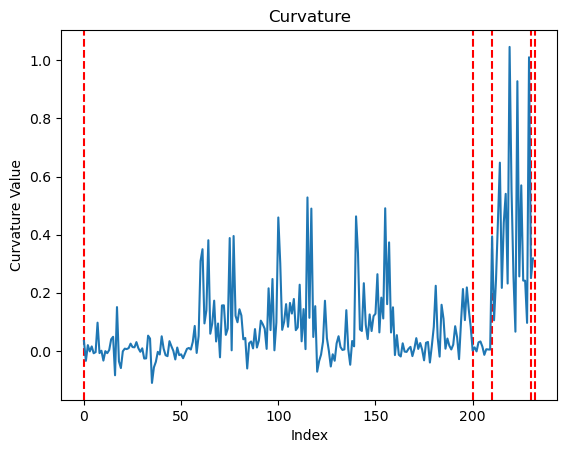

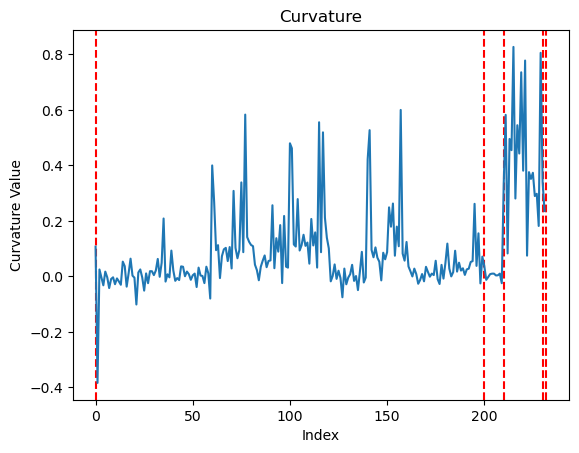

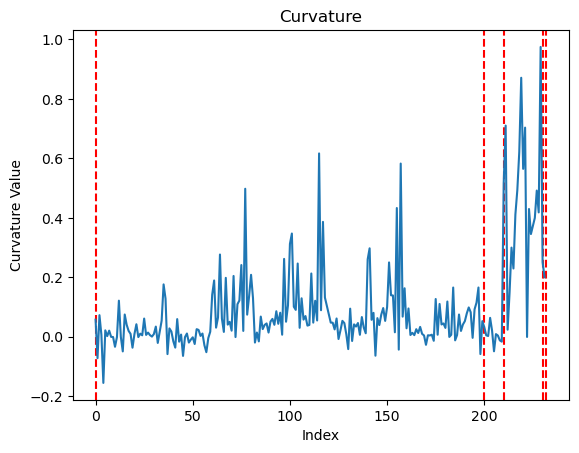

In [25]:
mean_curvature_SGD = mean_curvature(curvature_SGD)
mean_curvature_Adam = mean_curvature(curvature_Adam)
mean_curvature_curvy = mean_curvature(curvature_curvy)

model_distance_SGD = []
model_distance_Adam = []
model_distance_curvy = []

model_distance_SGD.append(distance(model_SGD, model_base))
model_distance_Adam.append(distance(model_Adam, model_base))
model_distance_curvy.append(distance(model_curvy, model_base))


plot_curvature(mean_curvature_SGD)
plot_curvature(mean_curvature_Adam)
plot_curvature(mean_curvature_curvy)

In [ ]:
optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr=1e-2)
optimizer_Adam = torch.optim.Adam(model_Adam.parameters(), lr=1e-2)
optimizer_curvy = torch.optim.SGD(model_curvy.parameters(), lr=1e-2)

epochs = 30
for epoch in range(epochs):
    model_SGD.train()
    model_Adam.train()
    model_curvy.train()

    running_loss_SGD = 0.0
    running_loss_Adam = 0.0
    running_loss_curvy = 0.0

    for i, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer_SGD.zero_grad()
        optimizer_Adam.zero_grad()
        optimizer_curvy.zero_grad()

        # Forward pass
        outputs_SGD = model_SGD(inputs)
        outputs_Adam = model_Adam(inputs)
        outputs_curvy = model_curvy(inputs)

        # Compute loss
        loss_SGD = criterion(outputs_SGD, labels)
        loss_Adam = criterion(outputs_Adam, labels)
        loss_curvy = criterion(outputs_curvy, labels)

        # Backward pass and optimize
        loss_SGD.backward()
        loss_Adam.backward()
        loss_curvy.backward()

        # parami = 0
        # s = 0
        for param, cur in zip(model_curvy.parameters(), mean_curvature_curvy):
            # if parami == 4:
            #     break
            if param.grad is None:
                continue
            # h_tensor = torch.from_numpy(cur).to(param.device).to(param.dtype)
            h_tensor = cur
            # s += torch.linalg.norm(1/torch.max(torch.abs(h_tensor), torch.ones_like(h_tensor) * 1e-2))
            param.grad = param.grad/torch.max(torch.abs(h_tensor), torch.ones_like(h_tensor) * 1e-2)
            # parami += 1

        # print(s)
                

        optimizer_SGD.step()
        optimizer_Adam.step()
        optimizer_curvy.step()


        running_loss_SGD += loss_SGD.item()
        running_loss_Adam += loss_Adam.item()
        running_loss_curvy += loss_curvy.item()

    train_losses_SGD.append(running_loss_SGD / len(dataloader))
    train_losses_Adam.append(running_loss_Adam / len(dataloader))
    train_losses_curvy.append(loss_curvy.item())

    model_distance_SGD.append(distance(model_SGD, model_base))
    model_distance_Adam.append(distance(model_Adam, model_base))
    model_distance_curvy.append(distance(model_curvy, model_base))

    print(f"Epoch [{epoch+1}/{epochs}], Loss SGD: {train_losses_SGD[-1]:.4f}, Loss Adam: {train_losses_Adam[-1]:.4f}, loss Curvy: {train_losses_curvy[-1]:.4f}")
    # Plot curvature array

    indices = torch.randperm(train_X.size(0))[:50]
    random_hessian_loader = (train_X[indices], train_y[indices])

    # hessian_SGD = hessian(model_SGD, criterion, data = random_hessian_loader, cuda=cuda)
    # hessian_Adam = hessian(model_Adam, criterion, data = random_hessian_loader, cuda=cuda)
    hessian_curvy = hessian(model_curvy, criterion, data = random_hessian_loader, cuda=cuda)

    # curvature_SGD = hessian_SGD.curvature_array(n_iter, 1e-3)
    # curvature_Adam = hessian_Adam.curvature_array(n_iter, 1e-3)
    curvature_curvy = hessian_curvy.curvature_array(n_iter, 1e-3)

    # mean_curvature_SGD = mean_curvature(curvature_SGD)
    # mean_curvature_Adam = mean_curvature(curvature_Adam)
    mean_curvature_curvy = mean_curvature(curvature_curvy)

    
    # print(type(mean_curvature_curvy[0]))
    # Finding trace:
    # trace = torch.sum(torch.stack([torch.sum(mean_curvature_curvy[i]) for i in range(len(mean_curvature_curvy))]))
    # trace.backward()
    # optimizer_curvy.step()
    # plot_curvature(mean_curvature_SGD, title = f'Curvature SGD epoch {epoch+1}')
    # plot_curvature(mean_curvature_Adam, title = f'Curvature Adam epoch {epoch+1}')
    # plot_curvature(mean_curvature_curvy, title = f'Curvature Curvy epoch {epoch+1}')

Epoch [1/30], Loss SGD: 0.7622, Loss Adam: 0.5633, loss Curvy: 0.4051
Epoch [2/30], Loss SGD: 0.6622, Loss Adam: 0.2933, loss Curvy: 0.2365
Epoch [3/30], Loss SGD: 0.6130, Loss Adam: 0.2169, loss Curvy: 0.2667
Epoch [4/30], Loss SGD: 0.5781, Loss Adam: 0.1849, loss Curvy: 0.1270
Epoch [5/30], Loss SGD: 0.5489, Loss Adam: 0.1596, loss Curvy: 0.0408
Epoch [6/30], Loss SGD: 0.5225, Loss Adam: 0.1652, loss Curvy: 0.3427
Epoch [7/30], Loss SGD: 0.4968, Loss Adam: 0.1414, loss Curvy: 0.2707
Epoch [8/30], Loss SGD: 0.4728, Loss Adam: 0.1260, loss Curvy: 0.2012
Epoch [9/30], Loss SGD: 0.4509, Loss Adam: 0.1165, loss Curvy: 0.0659
Epoch [10/30], Loss SGD: 0.4302, Loss Adam: 0.1184, loss Curvy: 0.1464
Epoch [11/30], Loss SGD: 0.4105, Loss Adam: 0.1017, loss Curvy: 0.0574
Epoch [12/30], Loss SGD: 0.3924, Loss Adam: 0.1099, loss Curvy: 0.1248
Epoch [13/30], Loss SGD: 0.3743, Loss Adam: 0.0838, loss Curvy: 0.0529
Epoch [14/30], Loss SGD: 0.3573, Loss Adam: 0.0757, loss Curvy: 0.0703
Epoch [15/30], 

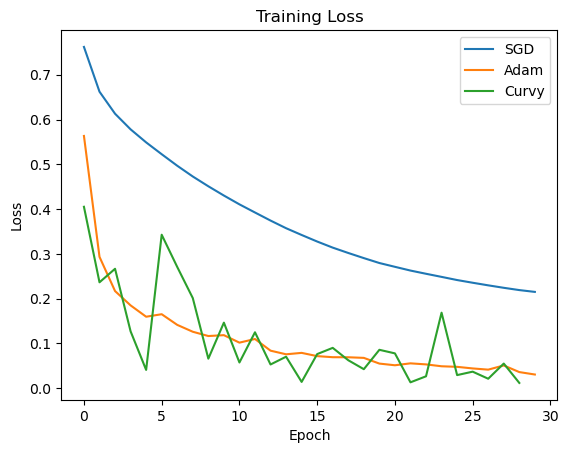

In [27]:
plt.plot(train_losses_SGD, label='SGD')
plt.plot(train_losses_Adam, label='Adam')
plt.plot(train_losses_curvy[:-1], label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

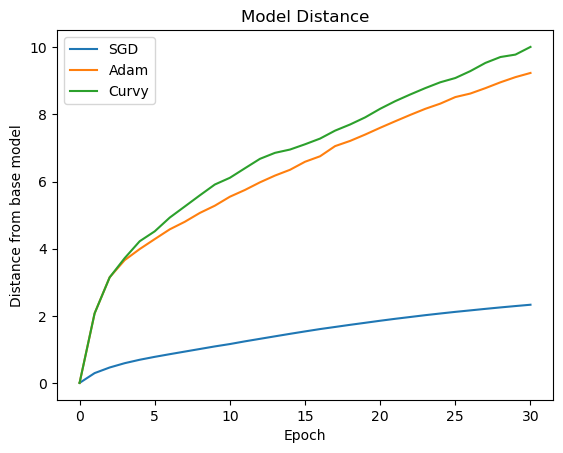

In [28]:
plt.plot([model_distance_SGD[i].detach().item() for i in range(len(model_distance_SGD))], label='SGD')
plt.plot([model_distance_Adam[i].detach().item() for i in range(len(model_distance_Adam))], label='Adam')
plt.plot([model_distance_curvy[i].detach().item() for i in range(len(model_distance_curvy))], label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Distance from base model')
plt.title('Model Distance')
plt.legend()
plt.show()

In [29]:
distance(model_SGD, model_Adam), distance(model_SGD, model_curvy), distance(model_Adam, model_curvy)

(tensor(7.9605, grad_fn=<AddBackward0>),
 tensor(8.7850, grad_fn=<AddBackward0>),
 tensor(5.2081, grad_fn=<AddBackward0>))

ValueError: x and y must have same first dimension, but have shapes (11,) and (20,)

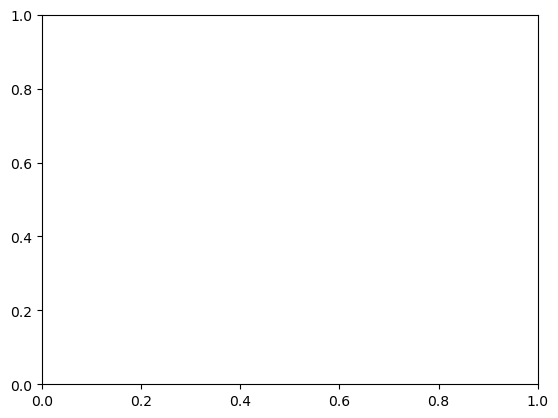

In [ ]:
def get_intermediate_model(model1, model2, alpha):
    """
    Get a model that is a linear combination of model1 and model2.
    """
    model = copy.deepcopy(model1)
    for param1, param2 in zip(model.parameters(), model2.parameters()):
        param1.data = (1 - alpha) * param1.data + alpha * param2.data
    return model


losses = []
for i in np.arange(0, 2, 0.1):
    model = get_intermediate_model(model_base, model_Adam, i)
    with torch.no_grad():
        loss = criterion(model(train_X), train_y)
        losses.append(loss.item())
plt.plot(np.arange(0, 2, 0.1), losses, label=f'alpha={i}')
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.title('Loss vs Alpha')
plt.legend()
plt.show()

